In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [43]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from bez.topo_graph import visualize_subgraph, extract_topology_from_skeleton, extract_simple_topology_from_skeleton, image_to_skeleton
from bez.graph_to_bezier import bezier_from_graph, visualize_bezier_fits
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.global_optim import optimisation

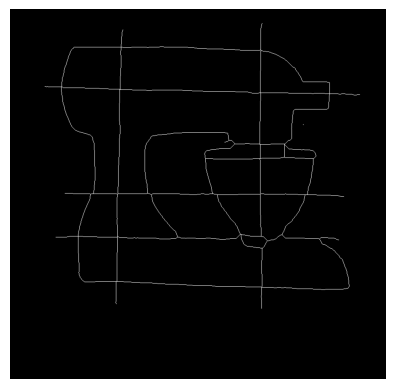

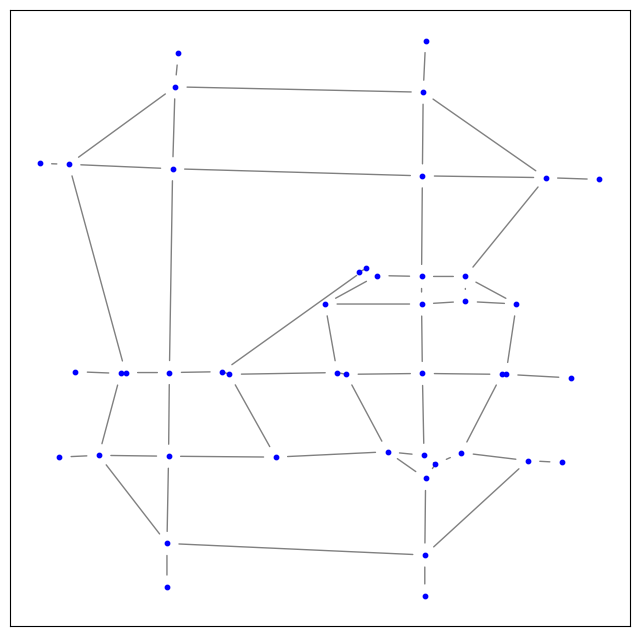

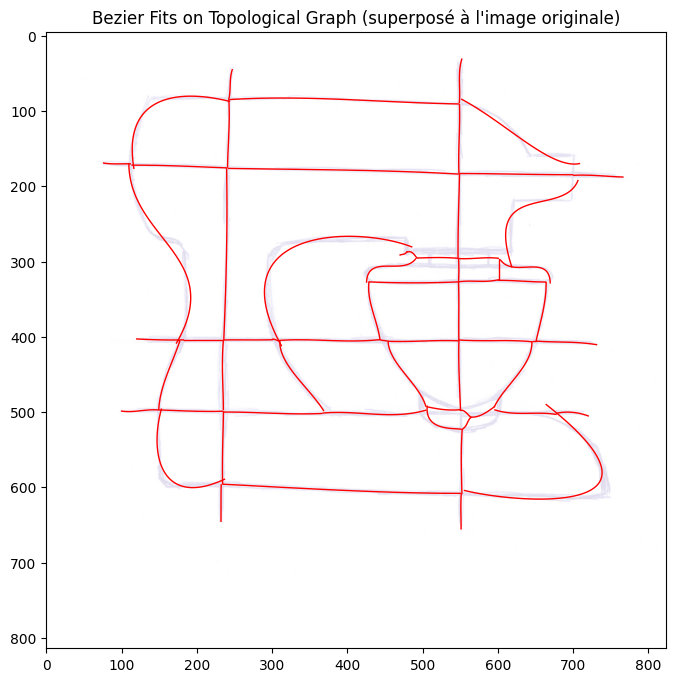

In [44]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png")

skeletone, thikness = image_to_skeleton(img)
plt.imshow(skeletone, cmap="gray")
plt.axis("off")
plt.show()

topo_graph = extract_simple_topology_from_skeleton(skeletone)
visualize_subgraph(topo_graph, full_graph=True)

bezier_curves = bezier_from_graph(topo_graph)
visualize_bezier_fits(img, bezier_curves)

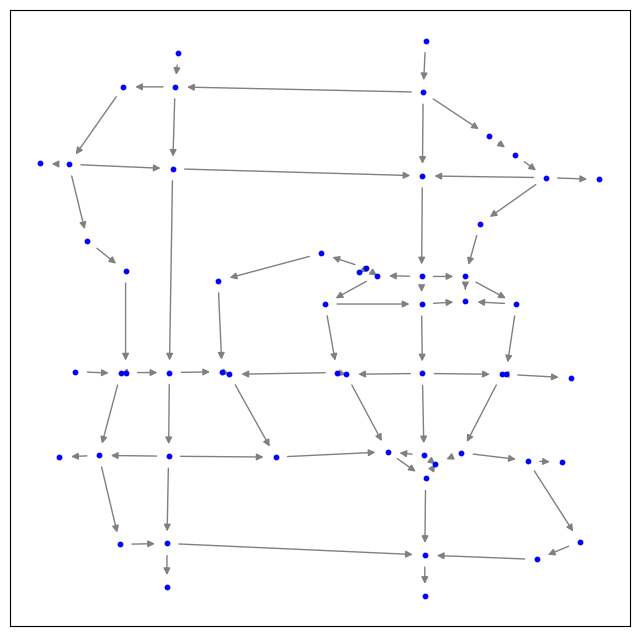

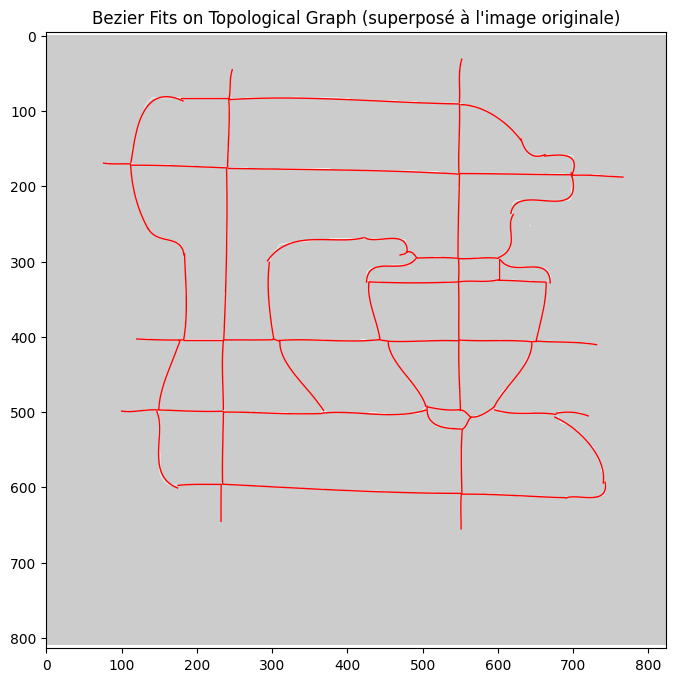

In [45]:
topo_graph = refine(topo_graph)
# visualize_subgraph(topo_graph, full_graph=True)
visualize_subgraph(topo_graph, full_graph=True)

new_bezier_curves = bezier_from_graph(topo_graph)
# visualize_bezier_fits(skeletone, bezier_curves)
visualize_bezier_fits(skeletone, new_bezier_curves)


In [46]:
hyper = HyperGraph(topo_graph)

# param
lam = 0.8
temp = 1
mu = 0.3
g_decrease = 0.998 ** (1/len(topo_graph.nodes))
t_min = 0.05


